In [ ]:
# Work Flow
# -- Dataloader Objects
# -- Training Loop
# -- Evaluation

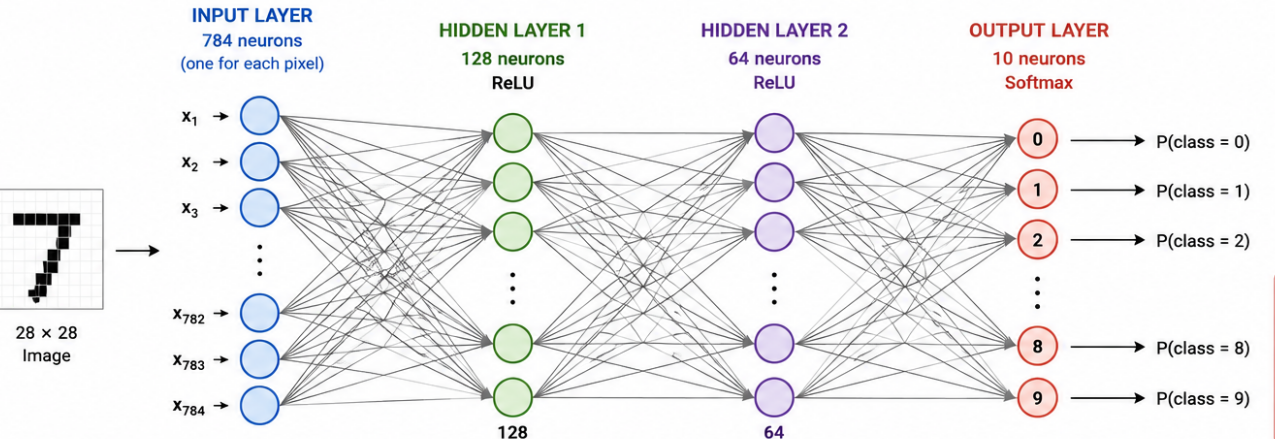

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [5]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


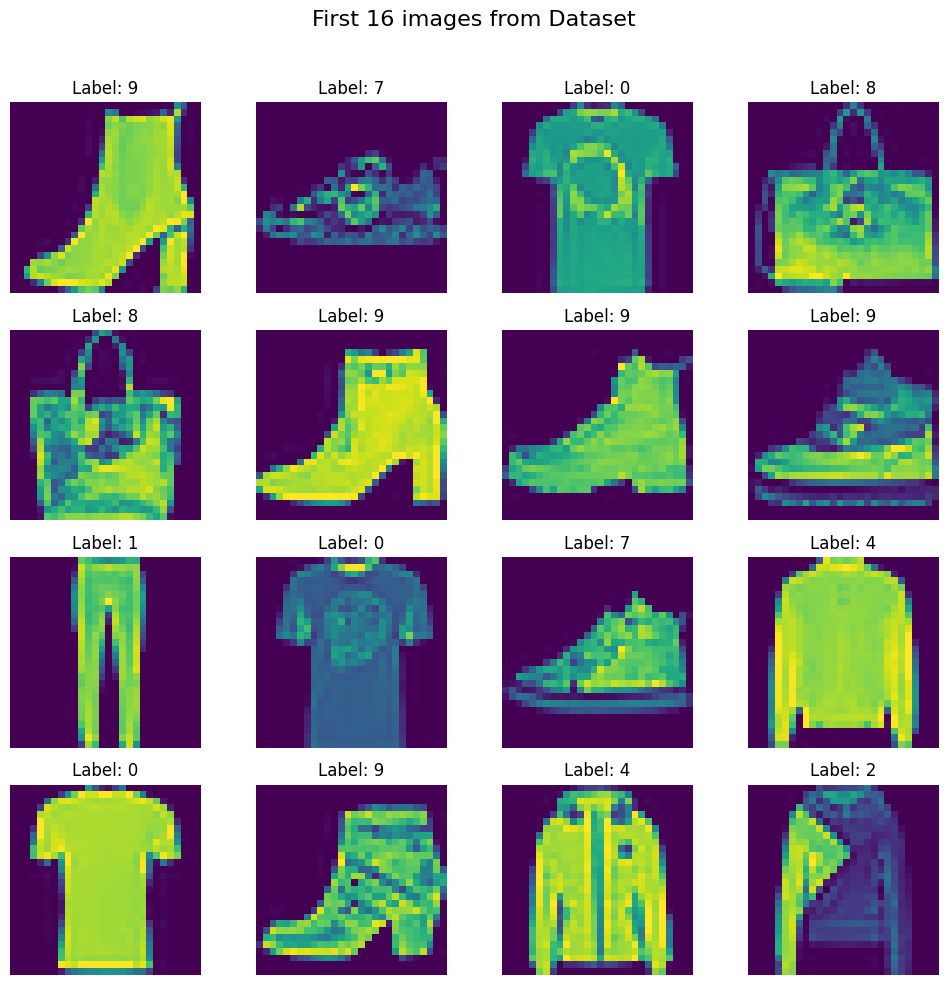

In [6]:
# Create image grid of size 4*4
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 images from Dataset", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(img)
  # above is for display in greyscale
  ax.axis('off')
  # remove the axis for a cleaner look
  ax.set_title(f"Label: {df.iloc[i, 0]}")
  # show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

Technically our image is 28*28 so if you flatten them then it is going to be 784 pixels, so each row is 1 label and 784 pixels, where label is which product this

fig, axes = plt.subplots(4, 4, figsize=(10,10))
So this gives us a plot of 4*4

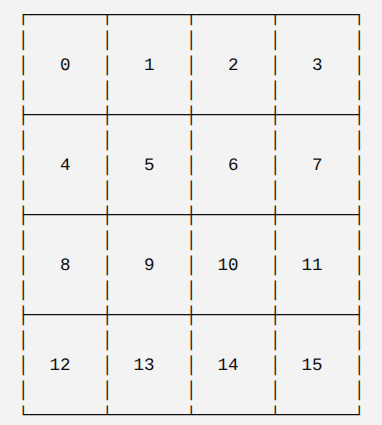



In [ ]:
# fig represents the whole figure. axes represents the individual plots/subplots. axes are like individual plots you create.
# where axes :
# [
#  [ax0, ax1, ax2, ax3],
#  [ax4, ax5, ax6, ax7],
#  [ax8, ax9, ax10, ax11],
#  [ax12, ax13, ax14, ax15]
# ]

# and axes.flat converts this into flatten from 2-dim to 1-dim
# ax0, ax1, ax2, ax3, ax4, ax5, ... ax15 [it can be looped now]
# and enumerate is just to get multiple values like index and stored data

In [ ]:
# img = df.iloc[i, 1:].values.reshape(28, 28)

# ==============================================================================================
# iloc is from pandas and it' used to select the rows and columns based on their index[instead of the labels]
# if df is like
#        name  age
# 0       A    20
# 1       B    25
# 2       C    30

# df.iloc[0]  -> A 20  where A and 20 are name and age respectively
# if we use single value in iloc then by default it takes that entire row as 0 means first row

# but if we specify two values then it is for row and column
# iloc[row, col]
# iloc[1, 0]  -> B  since row=1 and col=1  -> B similarly iloc[1,1] -> 25

# instead of just index values, we can use slicing
# iloc[:, 0]  it means all rows as [:]  -> every thing and col first
# A
# B
# C

# iloc[:1, 1:]
# :1 means all the rows before 1[exclusive]
# 1: means all the columns from 1[inclusive]
# A 20
# =================================================================================================
# img = df.iloc[i, 1:].values.reshape(28, 28)
#  df.iloc[i,1:] ([..,..,..] 784 values)(pandas series) take the ith row and take all the cols from 1 as 0th represents the label
#  df.iloc[i, 1:].values  -> converts the pandas data into numpy array
#  again .reshape converts the 784 pixels into 28*28 2D image matrix
# ax.imshow(img)  show the image on the particular plot  [ax is the plot]